# Config

In [1]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, START, END
import json
import os
import getpass
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel
from pprint import pprint

In [2]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your GOOGLE_API_KEY: ")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
model_with_search = model.bind_tools([{"google_search": {}}])

Enter your GOOGLE_API_KEY:  ········


In [3]:
#response

In [4]:
#prompt = "hello world"
#response = llm.invoke(prompt)

In [5]:
#response

In [6]:
# print(response.content)

In [7]:
# from openai import OpenAI
# import os
# client = OpenAI(
#     api_key='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',
#     base_url="https://api.groq.com/openai/v1",
# )
#prompt = "hello world"
#response = client.responses.create(
#    input=prompt,
#    model="openai/gpt-oss-20b",
#)
#print(response.output_text)


# Agents

**Point for discussion**: Query_Agent's prompt point 2 - given that sometimes speeches are written for announcement (e.g. new discovery), these information will not be available online and will be flagged as false. Thus, added point 2 where if the prompt implies/explicitly mentions that it's an announcement, it will skip fact checking for that specific piece of information. To discuss if we want to keep this.

In [8]:
class State(TypedDict):
    graph_state: str
    user_input: str
    query_facts: List[Dict[str, Any]]
    query_approved: bool
    query_attempts: int
    query_feedback: str
    plan: Dict[str, Any]

In [9]:
def Query_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    attempts = state.get("query_attempts",0)

    query_check_prompt = f"""
You are an expert fact-checking agent.

Your task is to analyse the details provided and identify factual claims.

Instructions:
1. Extract every factual claim from the details.
2. Check each claim for accuracy using reliable public sources.
3. Evaluate whether the claim is relevant to the occasion described.
4. If a claim refers to new information that is unlikely to be publicly available, do NOT attempt to fact-check it. Mark it as supported = null.
5. Return ONLY valid JSON. Following the output format strictly. Do not include explanations or text outside the JSON.

Details:
{user_input}

Output format:
{{
  "fact_results": [
    {{
      "serial_number": 1,
      "fact_identified": "<extracted factual claim>",
      "supported": <true | false | null>,
      "relevant": <true | false | null>,
      "source_url": "<URL used to verify the claim, or null if not checked>",
      "feedback": "<optional feedback>"
    }}
  ]
}}
    """

    response = model_with_search.invoke(query_check_prompt)
    # print("FACT RAW RESPONSE")
    # print(response.content)
    # print("------")
    fact_raw_response = response.content
    json_block = fact_raw_response[0]
    json_str = json_block.strip("```json").strip("```").strip()

    #print("json_str")
    print(json_str)
    print("TYPE", type(json_str))
    facts = json.loads(json_str)
    
    query_approved = True
    feedback_list = []
    
    # Iterate over the list of check results
    for item in facts["fact_results"]:
        if item.get("supported") is False or item.get("relevant") is False:
            query_approved = False
            feedback_list.append(
                f"Fact: {item.get('fact_identified','')}\n"
                f"Supported: {item.get('supported')}\n"
                f"Relevance: {item.get('relevant')}\n"
                f"Feedback: {item.get('feedback','')}"
            )
    
    query_feedback = "\n".join(feedback_list)
    
    return {
        "query_approved": query_approved,
        "query_feedback": query_feedback,
        "query_attempts": attempts + 1,
        "user_input": user_input,
        "query_facts": facts
    }


In [10]:
def Planner_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    query_facts = state.get("query_facts")
    planner_prompt = f"""
You are an expert speech coach.
Your task:
1. Given verified speech details, produce a structured speech plan.
2. Facts that have undergone fact-checking should be placed under "must_include_facts". All other content should be placed under "must_include_points".
3. estimated_wpm must be between 120 and 150.
4. target_word_count must be calculated using: time_limit_minutes * estimated_wpm.
5. Return ONLY valid JSON. Follow the JSON structure strictly. Do not include explanations or text outside the JSON.

Speech Details: {user_input}
Checked facts: {query_facts}

JSON structure:
{{
  "request": {{
    "topic": "",
    "audience": "",
    "occasion": "",
    "time_limit_minutes": ""
  }},
  "targets": {{
    "estimated_wpm": "",
    "target_word_count": ""
  }},
  "sections": [
    {{
      "section_id": "S1",
      "name": "",
      "purpose": "",
      "must_include_points": [],
      "must_include_facts": []
    }}
  ]
}}
"""
    response = llm.invoke(planner_prompt)
    print("RAW PLAN OUTPUT:")
    print(response.content)
    print("------")
    print("TYPE", type(response.content))
    content_str = response.content.strip()  # remove leading/trailing whitespace
    

    if content_str.startswith("```"):
        content_str = "\n".join(content_str.splitlines()[1:-1]).strip()
    

    plan = json.loads(content_str)
    
    pprint(plan)

    
    return {"plan": plan}

In [11]:
def collect_user_feedback(topic, audience, occasion, time_limit_in_minutes) -> str:
    revised_content = input("Revised Content to be included (i.e. Point, Examples and Facts):").strip()
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Revised Content:\n{revised_content}"
    )

In [12]:
def Human_Feedback(state: State) -> dict:
    print("\n" + "=" * 50)
    print("FACT-CHECK FAILED — Amendment required")
    print("=" * 50)
    print(f"{state.get('query_feedback', 'No feedback provided.')}")
    print()
    print("Please re-enter your speech content with the issues fixed.")

    # Extract existing values from state
    existing_input = state.get("user_input", "")
    parsed = {}
    for line in existing_input.splitlines():
        for key in ["Topic", "Audience", "Occasion", "Time limit (in minutes)"]:
            if line.startswith(f"{key}:"):
                parsed[key] = line[len(f"{key}:"):].strip()

    updated_input = collect_user_feedback(
        topic=parsed.get("Topic", ""),
        audience=parsed.get("Audience", ""),
        occasion=parsed.get("Occasion", ""),
        time_limit_in_minutes=parsed.get("Time limit (in minutes)", ""),
    )

    return {
        "user_input":     updated_input,
        "graph_state":    updated_input,
        "query_approved": False,
        "query_feedback": "",
    }

# Graph Set up 

In [13]:
def route_user(state):
    approved = state.get("query_approved") or state.get("query_attempts", 0) >= 2
    return "approved" if approved else "rejected"

In [14]:
builder = StateGraph(State)
builder.add_node("Query_Agent", Query_Agent)
builder.add_node("Human_Feedback", Human_Feedback)
builder.add_node("Planner_Agent", Planner_Agent)


In [15]:
builder.add_edge(START, "Query_Agent")
builder.add_edge("Human_Feedback", "Query_Agent") 
builder.add_conditional_edges(
    "Query_Agent",
    route_user,
    {
        "approved": "Planner_Agent",
        "rejected": "Human_Feedback" # HITL - needs to go back to user with feedback
    }
)

In [16]:
builder.add_edge("Planner_Agent", END)

In [17]:
graph = builder.compile()

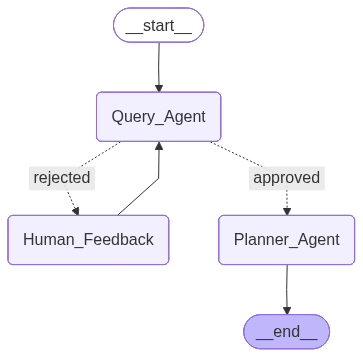

In [18]:
from IPython.display import Image, display
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
def collect_user_input() -> str:
    topic = input("Topic: ").strip()
    audience = input("Audience: ").strip()
    occasion = input("Occasion: ").strip()
    time_limit_in_minutes = input("Time limit (in minutes): ").strip()
    content = input("Content to be included (i.e. Point, Examples and Facts):").strip()

 
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Content:\n{content}"
    )

In [ ]:
def main():
    print("Speech Generator ready. Type 'quit' at any prompt to exit.\n")
 
    while True:
        try:
            user_input = collect_user_input()
        except (KeyboardInterrupt, EOFError):
            print("\nGoodbye!")
            break
 
        if user_input.strip().lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
 
        if not user_input.strip():
            continue
 
        print("\nChecking your content...\n")
 
        state: State = {
            "graph_state": user_input,
            "user_input": user_input,
            "query_approved": False,
            "query_attempts": 0,
            "query_feedback": "",
            "plan": "",
        }
 
        result = graph.invoke(state)
 
        # Surface feedback if fact-check hit the attempt limit without approving
        if not result.get("query_approved") and result.get("query_feedback"):
            print("Note: Some content could not be verified but the plan was generated anyway.")
            print(f"Feedback: {result['query_feedback']}\n")
 
        print("\n" + "=" * 50)
        print("YOUR SPEECH PLAN")
        print("=" * 50)
        plan = result.get("plan", "No plan generated.")
        print("TYPE", type(plan))
        #print(result.get("plan", "No plan generated."))
        if plan:
            # if plan is already a dict, pretty-print directly
            if isinstance(plan, dict):
                pprint(plan)
            # if plan is a JSON string, parse and pretty-print
            else:
                try:
                    plan_dict = json.loads(plan)
                    pprint(plan_dict)
                except json.JSONDecodeError:
                    # fallback to printing raw string
                    print(plan)
        else:
            print("No plan generated.")
 
        again = input("Generate another speech? (y/n): ").strip().lower()
        if again != "y":
            print("Goodbye!")
            break
 
 
if __name__ == "__main__":
    main()

Speech Generator ready. Type 'quit' at any prompt to exit.



Topic:  How Singapore can stay competitive by embracing Artificial Intelligence
Audience:  General public of Singaporeans
Occasion:  Singapore National Day Rally
Time limit (in minutes):  8
Content to be included (i.e. Point, Examples and Facts): Theme 1: We are entering a new era with AI Points: None Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive Points: Singapore's abili


Checking your content...

{
  "fact_results": [
    {
      "serial_number": 1,
      "fact_identified": "In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance.",
      "supported": true,
      "relevant": true,
      "source_url": "https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE02o3tou_VNAAZyRZo2XrZ8yH2_p22zFX0rybuKK3hT6aDE_MkcMe2_zeqCJ_fzn8XGGccrapSoQOJMRVC6oN71Q0gVvadiQGV0OF0CTRHd2lK3cxPGwVOfe3tw-QsSw73ZEaWA57WfzdlGHaTxWeHkAYiStAFEAccBMrG-9WlGTT7x4ddEcd2zI2jH7be3bSZinyZMF6_64kZZ9ihBWM=, https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE5FejNdNtUHBRFkRNe-p3CzZhCGy8-7cXN6TBhWz863acc0QtCVv5BDUDm3lCa2AML-8sESQgEXNblbF2ttHLkknQf6dLPyAvmkBTOmR7DgtRyE4muU4S9l-KNjXB1_e3TndicCaPyClCszkLzGTCQHXXZaCBPi_hlsz-27ibzxRYK0PEPBTE7WV69ZD1XpGibEly2TA==, https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQE8pNrCNFRGoCXSIRbnU_DnlGD

## Theme 1: We are entering a new era with AI 
### Points: None 
### Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. 
## Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive 
### Points: Singapore's ability to combine technology and human expertise attracts high-quality investments and creates good jobs. AI adoption is not limited to large companies, SMEs can also benefit. 
### Facts: AI is being combined with robotics and autonomous machines at Tuas Port and studied for automation at Changi Airport. GE Vernova's turbine repair facility in Singapore uses AI to detect anomalies in turbine components and alert human operators for precise diagnosis. SMEs like Q&M Dental use AI to analyse dental X-rays to help detect fillings, impacted teeth, and tooth decay more accurately. 
## Theme 3: Many people are concerned about job displacement due to AI, but there are opportunities from technological change 
### Points: Technological change in the past created disruption but also enabled workers to move into higher-skilled and better-paying jobs. 
### Facts: In the 1980s, Singapore launched a nationwide computerisation drive that equipped students and workers with computer skills and transformed the economy. When the internet arrived in the 1990s, Singapore successfully adopted it and propelled the nation forward. At PSA, crane operators were retrained to remotely supervise and manage multiple cranes and vehicles, boosting productivity and improving job quality. 
## Theme 4: Even as we embrace AI and technology, Singaporeans will always be our key priority 
### Points: The government will work closely with NTUC and unions to redesign jobs and equip workers with new skills. Efforts to help Singaporeans access jobs include expanded job matching services, more career fairs in tertiary institutions, and a new town-level job matching initiative led by CDCs. The SkillsFuture Level-Up Programme will expand to include more part-time training allowance claims and more courses from industry leaders and private training providers. 
### Facts: The SkillsFuture Level-Up Programme provides Singaporeans aged 40 and above with $4,000 in SkillsFuture credits and training allowances of up to $3,000 per month for up to 24 months for full-time study. Vinoth Nanda Kumaran, aged 41 in 2025, transitioned from private hire driver to Business Intelligence Developer after using SkillsFuture credits to pursue a diploma in data engineering and continuing his studies in Business Analytics at SUSS. 
## Theme 5: Embracing AI is in line with Singapore's broader strategy of building a dynamic, innovative economy that creates good jobs 
### Points: A dynamic economy is one that creates good jobs and better lives for all Singaporeans. Embracing AI supports Singapore's goal of staying globally competitive. Singapore aims to remain ahead through ideas, innovation, and unity. 
### Facts: None